<a href="https://colab.research.google.com/github/kcrajan19/Handwritten-Character-Recognition-/blob/main/Handwritten_Character_Recognition_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision



In [ ]:
import torch
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

print("Dataset loaded successfully!")


Dataset loaded successfully!


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

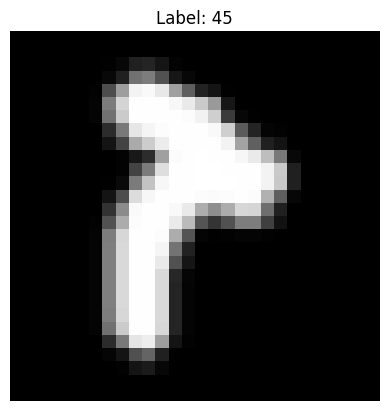

In [ ]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")


In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download crawford/emnist


Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
emnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rajankc1","key":"ac66db8cdb52200d398a04917f5c29ee"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d crawford/emnist


Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
emnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
n!unzip emnist.zip


Archive:  emnist.zip
replace emnist-balanced-mapping.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-balanced-test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-balanced-train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-byclass-mapping.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-byclass-test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-byclass-train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-bymerge-mapping.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-bymerge-test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-bymerge-train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-digits-mapping.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-digits-test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-digits-train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emnist-letters-mapping.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace emn

dataset unzipped complete

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


In [ ]:
!pip install extra-keras-datasets


In [ ]:

# Load the training and testing datasets from the local CSV files
train_df = pd.read_csv('emnist-letters-train.csv', header=None)
test_df = pd.read_csv('emnist-letters-test.csv', header=None)

# Separate features (x) and labels (y)
# The first column is the label, the rest are pixel data
x_train = train_df.iloc[:, 1:].values.astype('float32')
y_train = train_df.iloc[:, 0].values.astype('int32')
x_test = test_df.iloc[:, 1:].values.astype('float32')
y_test = test_df.iloc[:, 0].values.astype('int32')

# Normalize pixel values to [0, 1] and reshape to 28x28 images
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

# Adjust labels: EMNIST 'letters' labels are 1-based, convert to 0-based
y_train = y_train - 1
y_test = y_test - 1

print("EMNIST 'letters' dataset loaded successfully from local CSVs.")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

EMNIST 'letters' dataset loaded successfully from local CSVs.
x_train shape: (88800, 28, 28), y_train shape: (88800,)
x_test shape: (14800, 28, 28), y_test shape: (14800,)


In [ ]:
x_train = x_train[..., None]
x_test = x_test[..., None]

print(x_train.shape)


(88800, 28, 28, 1)


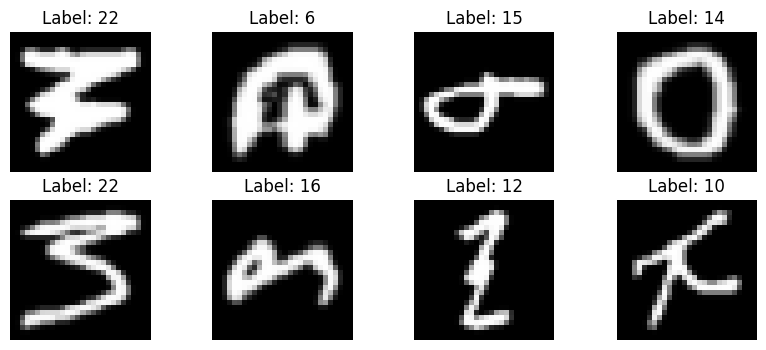

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(26, activation='softmax')
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    batch_size=128
)


Epoch 1/5
694/694 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6536 - loss: 1.1804 - val_accuracy: 0.8988 - val_loss: 0.2981
Epoch 2/5
694/694 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8949 - loss: 0.3309 - val_accuracy: 0.9151 - val_loss: 0.2491
Epoch 3/5
694/694 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9162 - loss: 0.2578 - val_accuracy: 0.9175 - val_loss: 0.2509
Epoch 4/5
694/694 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9246 - loss: 0.2251 - val_accuracy: 0.9244 - val_loss: 0.2255
Epoch 5/5
694/694 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9326 - loss: 0.1994 - val_accuracy: 0.9276 - val_loss: 0.2220


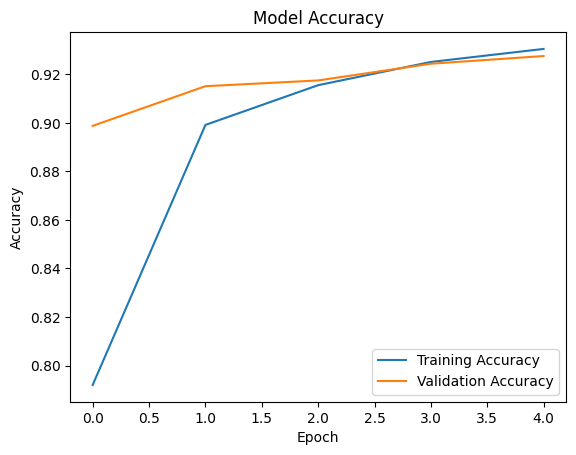

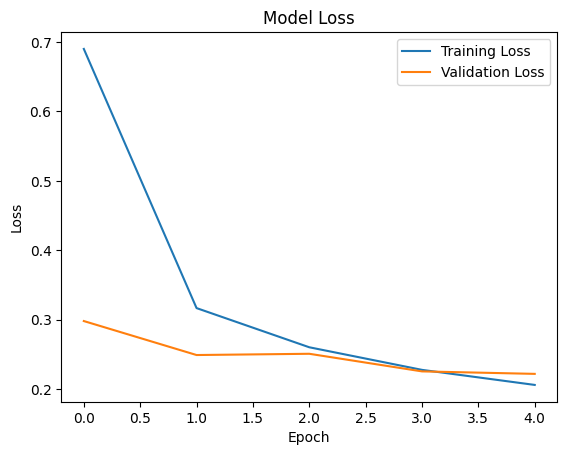

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.title('Model Accuracy')
plt.show()

# Loss graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.title('Model Loss')
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")


463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9333 - loss: 0.2316
Final Test Accuracy: 0.9276


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)


463/463 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


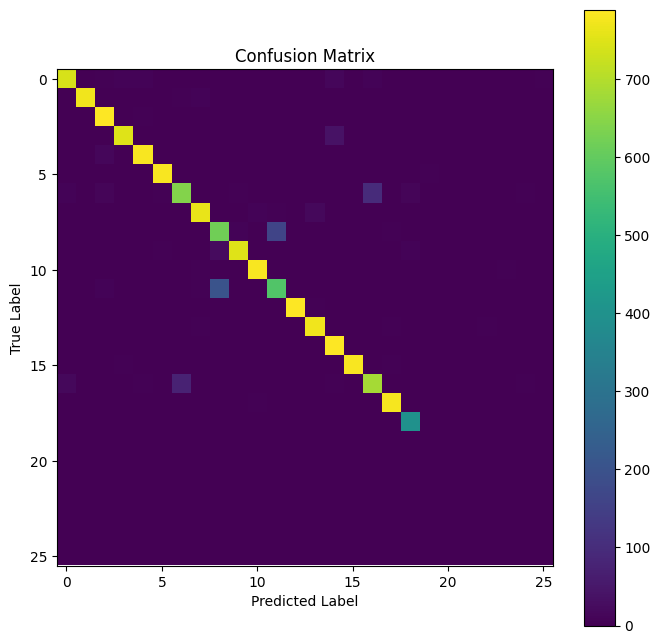

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(cm)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()


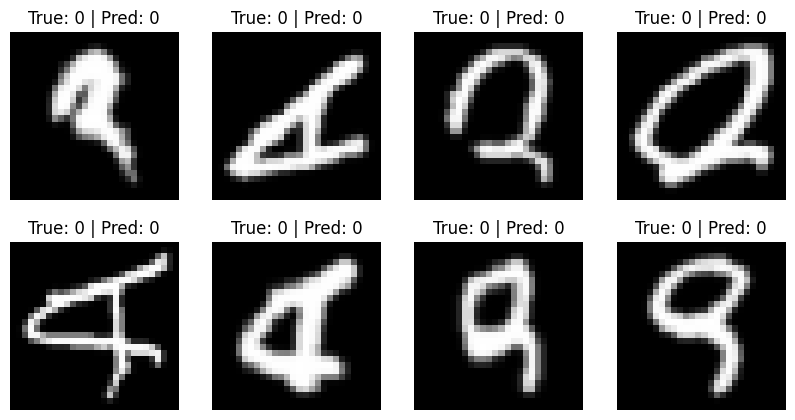

In [ ]:
plt.figure(figsize=(10,5))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f"True: {y_test[i]} | Pred: {y_pred[i]}")
    plt.axis('off')

plt.show()


In [ ]:
model.save("handwritten_character_model.h5")


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(26, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,994 (953.10 KB)

 Trainable params: 243,802 (952.35 KB)

 Non-trainable params: 192 (768.00 B)